<a href="https://colab.research.google.com/github/Hcxgraphics/Police_uniform/blob/main/Police_uniform.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
!pip install tensorflow keras roboflow


In [3]:
!pip install ultralytics roboflow -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.7/86.7 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 117.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 119.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 95.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/1

In [7]:
from roboflow import Roboflow
from ultralytics import YOLO
import os
import random
import matplotlib.pyplot as plt


In [8]:
!unzip /content/police-uniform.v2i.yolov8-obb.zip -d /content/dataset


Archive:  /content/police-uniform.v2i.yolov8-obb.zip
  inflating: /content/dataset/README.dataset.txt  
  inflating: /content/dataset/README.roboflow.txt  
  inflating: /content/dataset/data.yaml  
   creating: /content/dataset/test/
   creating: /content/dataset/test/images/
 extracting: /content/dataset/test/images/images-147-_jpeg.rf.79a298beeba4274654a2f7af43a51336.jpg  
 extracting: /content/dataset/test/images/images-152-_jpeg.rf.63f6e9c35b13cf768491d14193e86db3.jpg  
 extracting: /content/dataset/test/images/images-154-_jpeg.rf.3abaa97bc69769a73ffc05955ee74dc2.jpg  
 extracting: /content/dataset/test/images/images-157-_jpeg.rf.147f1824cdcb26393a4a6ec3578348a9.jpg  
 extracting: /content/dataset/test/images/images-158-_jpeg.rf.8b8829df8182b641d466432ab85fe4cb.jpg  
 extracting: /content/dataset/test/images/images-159-_jpeg.rf.19920782434ade3bf29f2aa82f359b0c.jpg  
 extracting: /content/dataset/test/images/images-161-_jpeg.rf.a41a8a0b0069fd011dbee5fa341c4916.jpg  
 extracting: /co

In [9]:
yaml_path = "/content/dataset/data.yaml"

In [10]:
# Check the contents of the data.yaml file
with open(yaml_path, 'r') as f:
    print(f.read())

print(f"YAML file created at: {yaml_path}")

train: train/images
val: valid/images
test: test/images

names: 
  0: police
YAML file created at: /content/dataset/data.yaml


In [12]:
from ultralytics import YOLO

# Load YOLOv8 nano model (small and fast)
model = YOLO('yolov8n.pt')

# Train the model on the police object detection dataset
results = model.train(
    data='/content/dataset/data.yaml',  # Replace with actual YAML path
    epochs=30,
    imgsz=640,
    batch=8,
    name="police_object_detection",
    workers=2,
    verbose=True
)

# Save the trained model (best.pt is automatically saved to the runs folder)
trained_model_path = model.ckpt_path if hasattr(model, "ckpt_path") else model.weights


Ultralytics 8.3.156 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=police_object_detection2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=

100%|██████████| 755k/755k [00:00<00:00, 18.1MB/s]

Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

 21                  -1  1    493056  ultralytics.nn.modules.block.C2f             [384, 256, 1]                 
 22        [15, 18, 21]  1    751507  ultralytics.nn.modules.head.Detect           [1, [64, 128, 256]]           
Model summary: 129 layers, 3,011,043 parameters, 3,011,027 gradients, 8.2 GFLOPs

Transferred 319/355 items from pretrained weights
Freezing layer 'model.22.dfl.conv.weight'
AMP: running Automatic Mixed Precision (AMP) checks...


100%|██████████| 5.35M/5.35M [00:00<00:00, 82.9MB/s]


...

                   all         47         93      0.772      0.806      0.811      0.486



30 epochs completed in 0.085 hours.
Optimizer stripped from runs/detect/police_object_detection2/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/police_object_detection2/weights/best.pt, 6.2MB

Validating runs/detect/police_object_detection2/weights/best.pt...
Ultralytics 8.3.156 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 3/3 [00:00<00:00,  3.07it/s]


                   all         47         93      0.777      0.861      0.865      0.523
Speed: 0.3ms preprocess, 3.5ms inference, 0.0ms loss, 5.0ms postprocess per image
Results saved to runs/detect/police_object_detection2


FileNotFoundError: [Errno 2] No such file or directory: 'runs/detect/police_object_detection/weights/best.pt'

In [16]:
# Optional: Copy model to specific location
import shutil
shutil.copy(f'/content/runs/detect/police_object_detection2/weights/best.pt', '/content/drive/MyDrive/police_model.pt')


'/content/drive/MyDrive/police_model.pt'

Saving images (80).jpeg to images (80).jpeg

image 1/1 /content/images (80).jpeg: 384x640 4 polices, 9.5ms
Speed: 2.2ms preprocess, 9.5ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)


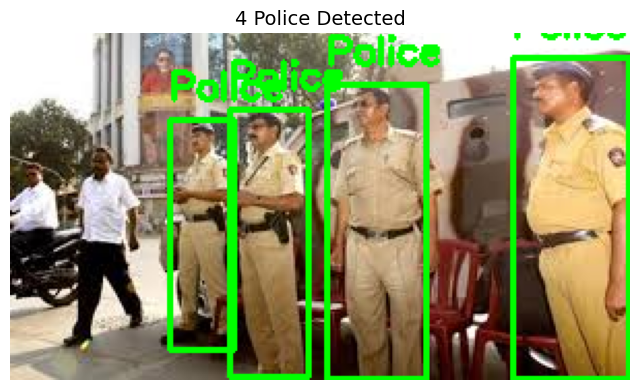

In [27]:
from ultralytics import YOLO
from google.colab import files
import cv2
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import numpy as np

# Load trained model
model = YOLO('/content/drive/MyDrive/police_model.pt')  # Update this path

# Upload image(s)
uploaded = files.upload()

# Set font for drawing text
font = cv2.FONT_HERSHEY_SIMPLEX

# Loop through images
for filename in uploaded.keys():
    # Run inference (no save)
    results = model.predict(source=filename, conf=0.4, save=False)

    for r in results:
        # Load original image
        img = cv2.imread(filename)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Get detections
        boxes = r.boxes
        count = len(boxes)

        # Draw bounding boxes
        for box in boxes:
            b = box.xyxy[0].cpu().numpy().astype(int)
            cv2.rectangle(img, (b[0], b[1]), (b[2], b[3]), (0, 255, 0), 2)
            cv2.putText(img, 'Police', (b[0], b[1] - 10), font, 0.6, (0, 255, 0), 2)

        # Show image
        plt.figure(figsize=(8, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f'{count} Police Detected', fontsize=14)
        plt.show()


Running inference on image: /content/dataset/valid/images/images-73-_jpeg.rf.bd11280b7f69b115e0369b3d95b13d04.jpg

image 1/1 /content/dataset/valid/images/images-73-_jpeg.rf.bd11280b7f69b115e0369b3d95b13d04.jpg: 640x544 1 police, 37.1ms
Speed: 1.9ms preprocess, 37.1ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 544)


array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[144, 134, 210],
        [145, 135, 211],
        [146, 137, 210],
        ...,
        [  1,   1,   1],
        [  1,   1,   1],
        [  1,   1,   1]],

       [[142, 132, 208],
        [143, 133, 209],
        [145, 136, 209],
        ...,
        [  1,   1,   1],
        [  1,   1,   1],
        [  1,   1,   1]],

       [[143, 133, 209],
        [144, 134, 210],
        [146, 137, 210],
        ...,
        [  1,   1,   1],
        [  1,   1,   1],
        [  1,   1,   1]]], dtype=uint8)
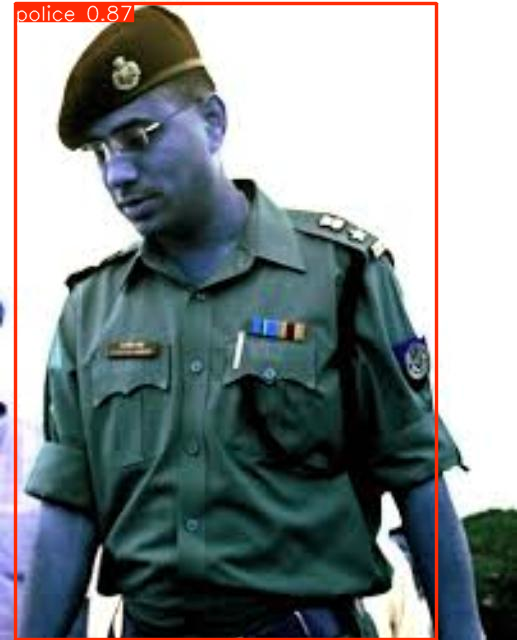

In [18]:
val_images_dir = "/content/dataset/valid/images"
val_images = [os.path.join(val_images_dir, f) for f in os.listdir(val_images_dir) if f.endswith(('.jpg', '.png'))]

img_path = random.choice(val_images)
print(f"Running inference on image: {img_path}")

results = model.predict(img_path)
results[0].plot()


In [5]:
#Don't RUN until unless you need complete extrction of detected objects in the frames

import cv2
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image
import numpy as np

# Upload images interactively
uploaded_files = files.upload()

# Load best trained YOLOv8-OBB model weights
best_weights = "/content/drive/MyDrive/police_model.pt"
model = YOLO(best_weights, task="detect")

for filename in uploaded_files.keys():
    print(f"Running detection on {filename}")

    # Helper function to print detection box coordinates
    def print_boxes(results):
        # Assuming results[0].boxes.xyxy or similar to get bounding boxes
        # Adjust according to the actual result format of your model
        boxes = results[0].boxes  # Access boxes object
        if boxes is not None and len(boxes) > 0:
            print(f"Detections coordinates in {filename}:")
            for i, box in enumerate(boxes.xyxy.cpu().numpy()):
                # Format xyxy box coordinates nicely
                x1, y1, x2, y2 = box
                print(f"  Box {i+1}: x1={x1:.1f}, y1={y1:.1f}, x2={x2:.1f}, y2={y2:.1f}")
            return True
        else:
            return False

    if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
        # Process image
        img = cv2.imread(filename)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Run prediction
        results = model.predict(img_rgb)

        # Only display if detections found
        if print_boxes(results):
            annotated_img = results[0].plot()

            plt.figure(figsize=(12, 8))
            plt.axis('off')
            plt.title(f"Detections for {filename}")
            plt.imshow(annotated_img)
            plt.show()

    elif filename.lower().endswith(('.mp4', '.avi', '.mov', '.mkv')):
        # Process video
        cap = cv2.VideoCapture(filename)
        frame_count = 0
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            frame_count += 1

            img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = model.predict(img_rgb)

            # Only display frames with detections
            if print_boxes(results):
                annotated_frame = results[0].plot()

                plt.figure(figsize=(12, 8))
                plt.axis('off')
                plt.title(f"Detections for {filename} - Frame {frame_count}")
                plt.imshow(annotated_frame)
                plt.show()

        cap.release()
    else:
        print(f"Unsupported file type for {filename}")



Saving images (163).jpeg to images (163).jpeg
Running detection on images (163).jpeg


TypeError: model='/content/drive/MyDrive/police_uniform_model' is not a supported model format. Ultralytics supports: ('PyTorch', 'TorchScript', 'ONNX', 'OpenVINO', 'TensorRT', 'CoreML', 'TensorFlow SavedModel', 'TensorFlow GraphDef', 'TensorFlow Lite', 'TensorFlow Edge TPU', 'TensorFlow.js', 'PaddlePaddle', 'MNN', 'NCNN', 'IMX', 'RKNN')
See https://docs.ultralytics.com/modes/predict for help.

Saving images (17).jpeg to images (17).jpeg

Processing: images (17).jpeg

0: 608x640 1 police, 39.1ms
Speed: 6.6ms preprocess, 39.1ms inference, 1.8ms postprocess per image at shape (1, 3, 608, 640)


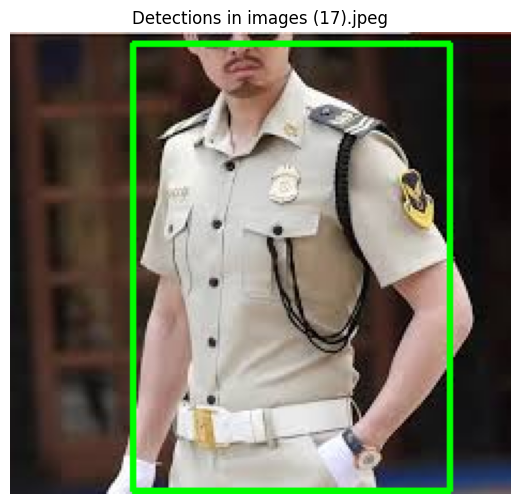

In [28]:
#Work with both videos and Images
import cv2
import datetime
from google.colab import files
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt

# # Load model
# best_weights = "runs/detect/police_uniform_detection/weights/best.pt"
# model = YOLO(best_weights)
# #model = YOLO('/content/drive/MyDrive/police_uniform_model', task='detect')

# Upload files
uploaded_files = files.upload()

def plot_detections(image, results):
    """Draw bounding boxes on image based on detection results"""
    for r in results:
        img_copy = image.copy()
        for box in r.boxes:
            # Get box coordinates
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
            # Draw rectangle
            cv2.rectangle(img_copy, (x1, y1), (x2, y2), (0, 255, 0), 2)
            # Get class label
            cls_id = int(box.cls[0])
            label = r.names[cls_id]
            # Put text label
            cv2.putText(img_copy, label, (x1, y1-10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
        return img_copy

for filename in uploaded_files.keys():
    print(f"\nProcessing: {filename}")

    if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
        # Process image
        img = cv2.imread(filename)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Run detection
        results = model.predict(img_rgb)

        # Visualize results
        if len(results[0].boxes) > 0:
            img_with_boxes = plot_detections(img_rgb, results)
            plt.figure(figsize=(10, 6))
            plt.imshow(img_with_boxes)
            plt.axis('off')
            plt.title(f"Detections in {filename}")
            plt.show()
        else:
            print("No detections in this image")

    elif filename.lower().endswith(('.mp4', '.avi', '.mov', '.mkv')):
        # Process video
        cap = cv2.VideoCapture(filename)
        fps = cap.get(cv2.CAP_PROP_FPS)
        detections = []

        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break

            frame_count = int(cap.get(cv2.CAP_PROP_POS_FRAMES))
            results = model.predict(frame)

            if len(results[0].boxes) > 0:
                timestamp = frame_count / fps
                detections.append((timestamp, frame))
                # Show first frame with detections only
                if len(detections) == 1:
                    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                    detected_frame = plot_detections(frame_rgb, results)
                    plt.figure(figsize=(10, 6))
                    plt.imshow(detected_frame)
                    plt.title(f"First detection at {str(datetime.timedelta(seconds=timestamp))}")
                    plt.axis('off')
                    plt.show()

        cap.release()

        if detections:
            print(f"Total detections: {len(detections)}")
            print(f"First detection at: {str(datetime.timedelta(seconds=detections[0][0]))}")
        else:
            print("No detections in video")

    else:
        print(f"Unsupported file type: {filename}")
